In [ ]:
import h5py as h5
import numpy as np
#COGER TODOS LOS DATOS DE LAS VELOCIDADES, CALCULAR LAS MEDIAS LOCALES Y LAS FLUCTUACIONES
# 1. Ruta a tu archivo maestro
ruta_maestra = r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5"

# Abrimos en modo 'a' (append) para poder añadir cosas nuevas sin borrar lo anterior
with h5.File(ruta_maestra, 'a') as f:
    
    print("1. Cargando las velocidades de la memoria...")
    u_total = f['sta']['probe_u'][:]
    v_total = f['sta']['probe_v'][:]
    w_total = f['sta']['probe_w'][:]
    
    print("2. Calculando las medias locales (Macro-flujo) para cada punto de la malla...")
    # axis=0 significa que hacemos la media a lo largo de la dimensión del TIEMPO.
    # El resultado es un "mapa 2D" (Y, Z) con la media constante de cada punto.
    u_media_local = np.mean(u_total, axis=0)
    v_media_local = np.mean(v_total, axis=0)
    w_media_local = np.mean(w_total, axis=0)
    
    print("3. Calculando las fluctuaciones (Micro-turbulencia)...")
    # NumPy es tan listo que automáticamente resta el "mapa 2D" a cada instante
    # de tiempo de la matriz 3D original. ¡Pura magia matemática!
    u_fluc = u_total - u_media_local
    v_fluc = v_total - v_media_local
    w_fluc = w_total - w_media_local

    print("4. Liberando RAM: Borrando matrices originales...")
    # Borramos las matrices totales porque ya no las necesitamos
    del u_total, v_total, w_total
    
    # Obligamos a Python a vaciar la "basura" de la RAM inmediatamente
    import gc
    gc.collect()

1. Cargando las velocidades de la memoria...
2. Calculando las medias locales (Macro-flujo) para cada punto de la malla...
3. Calculando las fluctuaciones (Micro-turbulencia)...
4. Liberando RAM: Borrando matrices originales...


In [ ]:
# 2. CÁLCULO DE LA AUTOCORRELACIÓN (Usando la fluctuación)
# 1. Inicializamos las variables necesarias

dim_y, dim_z = u_fluc.shape[1], u_fluc.shape[2]  # Dimensiones espaciales (Y, Z)

pasos_maximos = 3000 # Número máximo de pasos de tiempo a evaluar

# 2. Preparación de las matrices de resultados
mapa_coherencia_u = np.full((dim_y, dim_z), pasos_maximos, dtype=int)
mapa_coherencia_v = np.full((dim_y, dim_z), pasos_maximos, dtype=int)
mapa_coherencia_w = np.full((dim_y, dim_z), pasos_maximos, dtype=int)

# ya_encontrado actúa como un "check" para no volver a evaluar puntos ya resueltos
ya_encontrado_u = np.zeros((dim_y, dim_z), dtype=bool)
ya_encontrado_v = np.zeros((dim_y, dim_z), dtype=bool)
ya_encontrado_w = np.zeros((dim_y, dim_z), dtype=bool)

# 3. El bucle de cálculo
for k in range(1, pasos_maximos):
    
    # --- CÁLCULO PARA U ---
    covarianza_u = np.sum(u_fluc[:-k, :, :] * u_fluc[k:, :, :], axis=0)
    cruzaron_u = (covarianza_u < 0) & (~ya_encontrado_u)
    mapa_coherencia_u[cruzaron_u] = k
    ya_encontrado_u[cruzaron_u] = True

    # --- CÁLCULO PARA V ---
    covarianza_v = np.sum(v_fluc[:-k, :, :] * v_fluc[k:, :, :], axis=0)
    cruzaron_v = (covarianza_v < 0) & (~ya_encontrado_v)
    mapa_coherencia_v[cruzaron_v] = k
    ya_encontrado_v[cruzaron_v] = True

    # --- CÁLCULO PARA W ---
    covarianza_w = np.sum(w_fluc[:-k, :, :] * w_fluc[k:, :, :], axis=0)
    cruzaron_w = (covarianza_w < 0) & (~ya_encontrado_w)
    mapa_coherencia_w[cruzaron_w] = k
    ya_encontrado_w[cruzaron_w] = True

    # Mensaje de progreso (opcional, para saber que no se ha colgado)
    if k % 500 == 0:
        print(f" -> Procesando paso k = {k}...")

    # Condición de salida rápida: Si el 100% de la malla ya cruzó el cero en las TRES velocidades
    if np.all(ya_encontrado_u) and np.all(ya_encontrado_v) and np.all(ya_encontrado_w):
        print(f"✅ Búsqueda finalizada anticipadamente en el paso {k}. Todos los puntos cruzaron el cero.")
        break

# ESTO VA FUERA DEL BUCLE FOR
if not (np.all(ya_encontrado_u) and np.all(ya_encontrado_v) and np.all(ya_encontrado_w)):
    print(f"⚠️ Nota: Algunos puntos no llegaron a cruzar el cero en los {pasos_maximos} pasos.")

 -> Procesando paso k = 500...
 -> Procesando paso k = 1000...
 -> Procesando paso k = 1500...
 -> Procesando paso k = 2000...
 -> Procesando paso k = 2500...
⚠️ Nota: Algunos puntos no llegaron a cruzar el cero en los 3000 pasos.


In [ ]:
# ==========================================
# CÁLCULO DE AUTOCORRELACIÓN AISLADO (Variable U, Línea idy = 2)
# ==========================================

linea_idy = 2
pasos_maximos = 3000 # Número máximo de pasos de tiempo a evaluar

print(f"🔍 Analizando la longitud de autocorrelación para U en la línea idy = {linea_idy}...")

# 1. Extraemos SOLO la línea idy = 2 para la fluctuación de U
# Suponiendo que u_fluc tiene forma (Tiempo, Y, Z)
u_linea = u_fluc[:, linea_idy, :] 
dim_z_linea = u_linea.shape[1] # Cuántos puntos espaciales hay en esa línea

# 2. Inicializamos vectores de seguimiento (ahora es 1D, súper ligero)
mapa_coherencia_u = np.full(dim_z_linea, pasos_maximos, dtype=int)
ya_encontrado_u = np.zeros(dim_z_linea, dtype=bool)

# 3. El bucle de cálculo (volará porque solo calcula una línea)
for k in range(1, pasos_maximos):
    
    # Calculamos la covarianza desplazando k pasos temporales
    covarianza_u = np.sum(u_linea[:-k, :] * u_linea[k:, :], axis=0)
    
    # Detectamos quién acaba de cruzar el cero por primera vez
    cruzaron_u = (covarianza_u < 0) & (~ya_encontrado_u)
    
    # Registramos el paso k y marcamos como encontrado
    mapa_coherencia_u[cruzaron_u] = k
    ya_encontrado_u[cruzaron_u] = True

    # Condición de salida ultrarrápida: Si toda la línea ya cruzó
    if np.all(ya_encontrado_u):
        print(f"✅ Todos los puntos de la línea cruzaron el cero en el paso {k}.")
        break

# ==========================================
# 4. CÁLCULO DE LA MEDIA ESTRICTA
# ==========================================
print("-" * 50)
if np.any(ya_encontrado_u):
    # Hacemos la media SOLO con los puntos que realmente llegaron al cero
    media_u_linea = np.mean(mapa_coherencia_u[ya_encontrado_u])
    
    print(f"🌊 LONGITUD MEDIA DE AUTOCORRELACIÓN (U, IDY={linea_idy}): {media_u_linea:.2f} time steps")
    print("-" * 50)
else:
    print(f"⚠️ Alerta: Ningún punto de la línea idy={linea_idy} llegó a cruzar el cero.")
    print("-" * 50)

<>:74: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:74: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\MSI\AppData\Local\Temp\ipykernel_2548\1704604412.py:74: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title('VERIFICACIÓN 3: Fluctuaciones puras de Velocidad ($u^\prime$)')


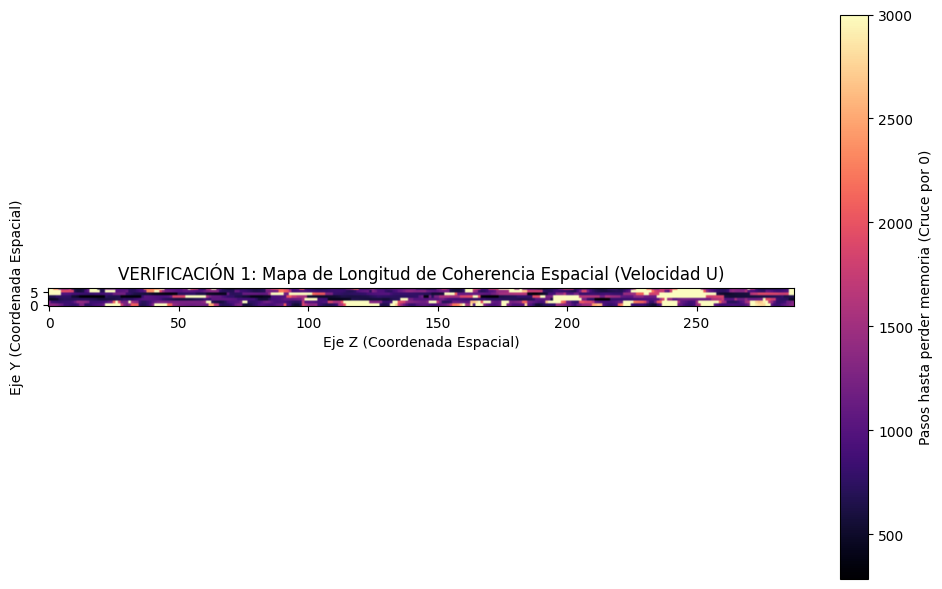

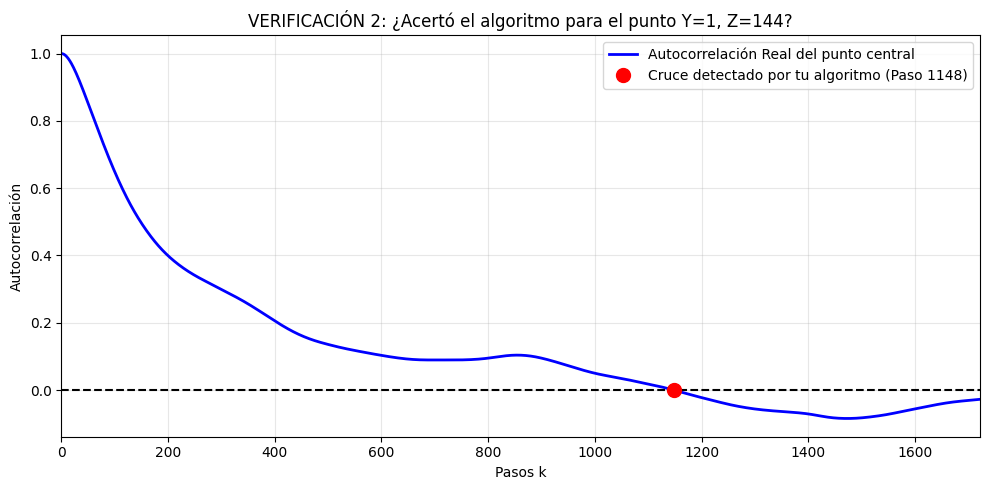

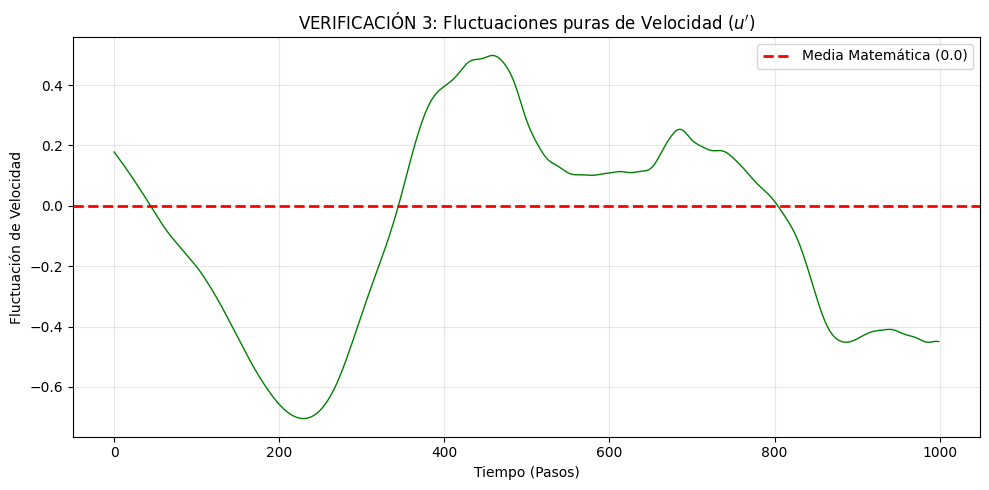

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 4. GRÁFICAS PARA COMPROBAR QUE TODOS LOS DATOS SON CORRECTOS Y QUE EL ALGORITMO FUNCIONA BIEN

# ==========================================
# GRÁFICA 1: EL MAPA TÉRMICO (FÍSICA GLOBAL)
# ==========================================
# Comprueba que el fluido tiene sentido espacial. 
# Lo normal es ver valores bajos (oscuros) en los bordes por la fricción, 
# y valores altos (brillantes) en el centro del canal.

plt.figure(figsize=(10, 6))
# CAMBIO AQUÍ: Usamos mapa_coherencia_u
plt.imshow(mapa_coherencia_u, cmap='magma', origin='lower')
plt.colorbar(label='Pasos hasta perder memoria (Cruce por 0)')
plt.title('VERIFICACIÓN 1: Mapa de Longitud de Coherencia Espacial (Velocidad U)')
plt.xlabel('Eje Z (Coordenada Espacial)')
plt.ylabel('Eje Y (Coordenada Espacial)')
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: LA PRUEBA DEL ALGODÓN (MATEMÁTICA)
# ==========================================
# Vamos a coger el punto central, miraremos qué valor dice la matriz 'mapa_coherencia_u' 
# que tiene, y luego calcularemos su curva clásica para ver si coinciden EXACTAMENTE.

centro_y, centro_z = 1, dim_z // 2
# CAMBIO AQUÍ: Usamos mapa_coherencia_u
paso_predicho = mapa_coherencia_u[centro_y, centro_z]

# Extraemos la señal fluctuante de ese punto
u_prueba = u_fluc[:, centro_y, centro_z]
N = len(u_prueba)

# Calculamos su curva de autocorrelación hasta un poco después de su cruce por cero
pasos_plot = int(paso_predicho * 1.5) 
autocorr_prueba = np.zeros(pasos_plot)

for k in range(pasos_plot):
    if k == 0:
        autocorr_prueba[k] = np.sum(u_prueba * u_prueba) / N
    else:
        autocorr_prueba[k] = np.sum(u_prueba[:-k] * u_prueba[k:]) / (N - k)
autocorr_prueba = autocorr_prueba / autocorr_prueba[0]

plt.figure(figsize=(10, 5))
plt.plot(autocorr_prueba, label='Autocorrelación Real del punto central', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--')

# Dibujamos el punto donde el algoritmo gigante dijo que cruzaba
plt.plot(paso_predicho, 0, 'ro', markersize=10, 
         label=f'Cruce detectado por tu algoritmo (Paso {paso_predicho})')

plt.title(f'VERIFICACIÓN 2: ¿Acertó el algoritmo para el punto Y={centro_y}, Z={centro_z}?')
plt.xlabel('Pasos k')
plt.ylabel('Autocorrelación')
plt.xlim(0, pasos_plot)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 3: HISTORIAL DE TURBULENCIA
# ==========================================
# Vamos a ver los primeros 1000 pasos de ese mismo punto para ver 
# que realmente oscila alrededor del cero perfecto.

plt.figure(figsize=(10, 5))
plt.plot(u_prueba[:1000], color='green', linewidth=1)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Media Matemática (0.0)')
plt.title('VERIFICACIÓN 3: Fluctuaciones puras de Velocidad ($u^\prime$)')
plt.xlabel('Tiempo (Pasos)')
plt.ylabel('Fluctuación de Velocidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. GUARDAR TODO EN EL ARCHIVO MAESTRO (HDF5)
# ==========================================
# 1. Ruta de tu archivo maestro
ruta_maestra = r"C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5"

with h5.File(ruta_maestra, 'a') as f:
    
    # 2. Creamos o accedemos a la "carpeta" (grupo) principal de análisis
    if 'data_analisis' not in f:
        grupo = f.create_group('data_analisis')
    else:
        grupo = f['data_analisis']
    
    print("Guardando datos en el archivo maestro...")

    # 3. Función auxiliar para guardar/sobrescribir datasets sin errores
    def guardar_dataset(nombre, datos, comprimir=False):
        if nombre in grupo:
            del grupo[nombre] # Borramos si ya existe para actualizarlo
        
        if comprimir:
            # Usamos compresión para matrices 3D (ahorra mucho espacio)
            grupo.create_dataset(nombre, data=datos, compression="gzip", chunks=True)
        else:
            # Para mapas 2D o medias no hace falta tanta compresión
            grupo.create_dataset(nombre, data=datos)
        print(f" -> '{nombre}' guardado correctamente.")

    # 4. GUARDAMOS LAS MEDIAS LOCALES (Mapas 2D)
    # Útiles para reconstruir la velocidad real después de la predicción
    guardar_dataset('u_local_media', u_media_local)
    guardar_dataset('v_local_media', v_media_local)
    guardar_dataset('w_local_media', w_media_local)

    # 5. GUARDAMOS LAS FLUCTUACIONES (Matrices 3D)
    # Este es el alimento principal de tu Red Neuronal
    guardar_dataset('u_fluc', u_fluc, comprimir=True)
    guardar_dataset('v_fluc', v_fluc, comprimir=True)
    guardar_dataset('w_fluc', w_fluc, comprimir=True)

    # 6. GUARDAMOS EL MAPA DE COHERENCIA (Mapa 2D)
    # Contiene el "paso de pérdida de memoria" para cada punto
    guardar_dataset('mapa_coherencia_u', mapa_coherencia_u)
    guardar_dataset('mapa_coherencia_v', mapa_coherencia_v)
    guardar_dataset('mapa_coherencia_w', mapa_coherencia_w)

print("-" * 50)
print("✅ ¡PROCESO COMPLETADO!")
print(f"Todo está organizado en {ruta_maestra} dentro del grupo '/data_analisis'")

Guardando datos en el archivo maestro...
 -> 'u_local_media' guardado correctamente.
 -> 'v_local_media' guardado correctamente.
 -> 'w_local_media' guardado correctamente.
 -> 'u_fluc' guardado correctamente.
 -> 'v_fluc' guardado correctamente.
 -> 'w_fluc' guardado correctamente.
 -> 'mapa_coherencia_u' guardado correctamente.
 -> 'mapa_coherencia_v' guardado correctamente.
 -> 'mapa_coherencia_w' guardado correctamente.
--------------------------------------------------
✅ ¡PROCESO COMPLETADO!
Todo está organizado en C:\Users\MSI\Downloads\Proyecto_Fluidos_AI\datos_procesados\process_data.h5 dentro del grupo '/data_analisis'
